# 04 - Content Quality Analytics

# Digikala Content Analytics & AI Insight Platform


## Business Context


In e-commerce platforms, content quality directly affects:

- Customer trust
- Product discoverability
- Conversion rate
- User experience


A product with incomplete or low-quality information
can reduce customer confidence and increase purchase friction.


The Content Analytics team needs measurable KPIs
to monitor and improve product content quality.



## Objective


The goal of this notebook is to:


- Define content quality indicators
- Measure product information completeness
- Create a Content Quality Score
- Identify categories requiring content improvement
- Generate actionable recommendations



## Business Questions


1. Which products have incomplete content?


2. Which categories have lower content quality?


3. Where should content teams prioritize improvements?


4. Can we create a measurable Content Quality KPI?



## Workflow


Product Data

↓

Feature Analysis

↓

Content Quality Score

↓

Category Ranking

↓

Business Recommendations


In [1]:
# Import Libraries

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


import warnings

warnings.filterwarnings("ignore")


pd.set_option(
    "display.max_columns",
    None
)


print("Libraries imported successfully")

Libraries imported successfully


# 1. Load Processed Data


We use the cleaned product dataset
generated in previous notebooks.


In [2]:
DATA_PATH = "../data/processed/"


products = pd.read_csv(
    DATA_PATH +
    "products_clean.csv"
)


products.head()

,id,title_fa,Rate,Rate_cnt,Category1,Category2,Brand,Price,Seller,Is_Fake,min_price_last_month,sub_category
0,7096438,آبسلانگ مدل s5 بسته 250 عددی,90,4,آبسلانگ,NaN,متفرقه,634800,سلامت ساز راد,False,0,beauty
1,2845119,آبسلانگ مدل M-1 بسته 400 عددی,84,217,آبسلانگ,NaN,متفرقه,818800,مهر افزون,False,0,beauty
2,6117745,آبسلانگ مدل m50 مجموعه 500 عددی,88,14,آبسلانگ,NaN,متفرقه,920000,یانگوم,False,0,beauty
3,1912926,استند ابسلانگ مدل S01,78,25,آبسلانگ,NaN,متفرقه,1100000,بهراد طب بیدار,False,0,beauty
4,6335462,آبسلانگ نوری تسلامد مدل All-in-One,84,25,آبسلانگ,NaN,تسلا مد,1530000,دیجی‌کالا,False,0,beauty


# 2. Dataset Overview


Before creating metrics,
we inspect available content-related features.


In [4]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960367 entries, 0 to 960366
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   id                    960367 non-null  int64 
 1   title_fa              960367 non-null  object
 2   Rate                  960367 non-null  int64 
 3   Rate_cnt              960367 non-null  int64 
 4   Category1             960367 non-null  object
 5   Category2             778477 non-null  object
 6   Brand                 960367 non-null  object
 7   Price                 960367 non-null  int64 
 8   Seller                960169 non-null  object
 9   Is_Fake               960367 non-null  bool  
 10  min_price_last_month  960367 non-null  int64 
 11  sub_category          960367 non-null  object
dtypes: bool(1), int64(5), object(6)
memory usage: 81.5+ MB


In [5]:
products.isnull().sum()

id                           0
title_fa                     0
Rate                         0
Rate_cnt                     0
Category1                    0
Category2               181890
Brand                        0
Price                        0
Seller                     198
Is_Fake                      0
min_price_last_month         0
sub_category                 0
dtype: int64

# 3. Content Quality Framework


A product page quality can be evaluated
based on several dimensions:


## Information Completeness

Does the product contain required information?


Examples:

- Product title
- Category
- Brand
- Seller
- Price



## Reliability Indicators

Examples:

- Customer rating
- Number of ratings
- Fake product indicator



## Content Opportunity


Products with:

- Missing information
- Low ratings
- High marketplace importance


should receive higher improvement priority.


# 4. Feature Completeness Analysis


We identify missing content fields.

A complete product page should contain:

- Title
- Brand
- Category
- Seller
- Price


In [6]:
content_features = [
    "title_fa",
    "Category1",
    "Brand",
    "Seller",
    "Price"
]


content_missing = (
    products[content_features]
    .isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)


content_missing

Seller       198
title_fa       0
Category1      0
Brand          0
Price          0
dtype: int64

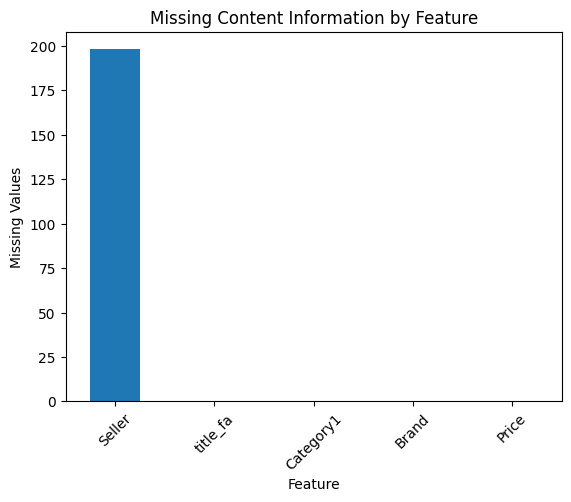

In [7]:
content_missing.plot(
    kind="bar"
)


plt.title(
    "Missing Content Information by Feature"
)


plt.xlabel(
    "Feature"
)


plt.ylabel(
    "Missing Values"
)


plt.xticks(rotation=45)

plt.show()

# 5. Creating Content Completeness Score


We create a simple KPI:


Content Completeness Score =


(Number of available content fields)
/
(Total required content fields)


Range:

0 = incomplete

1 = complete



In [8]:
products["content_completeness_score"] = (

    products[content_features]
    .notnull()
    .sum(axis=1)

    /

    len(content_features)

)


products[
    "content_completeness_score"
].describe()

count    960367.000000
mean          0.999959
std           0.002871
min           0.800000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: content_completeness_score, dtype: float64

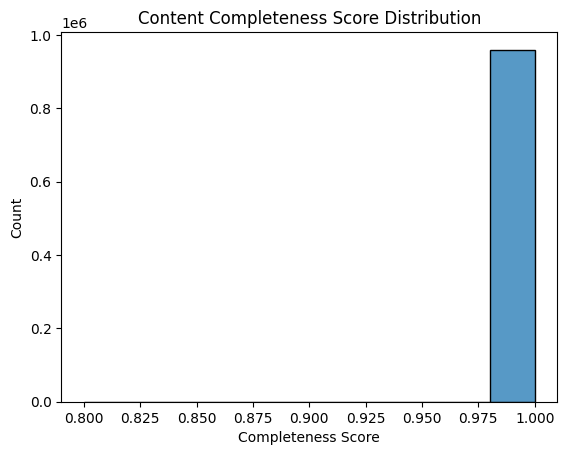

In [9]:
sns.histplot(
    products["content_completeness_score"],
    bins=10
)


plt.title(
    "Content Completeness Score Distribution"
)


plt.xlabel(
    "Completeness Score"
)


plt.show()

# 6. Content Quality Score


A more comprehensive KPI combines:


- Content completeness
- Customer rating
- Engagement level


The goal is creating a ranking
for content improvement opportunities.


In [10]:
products["normalized_rating"] = (

    products["Rate"]

    /

    products["Rate"].max()

)


products["Content_Quality_Score"] = (

    0.6 *
    products["content_completeness_score"]

    +

    0.4 *
    products["normalized_rating"]

)


products[
    [
        "Content_Quality_Score",
        "Rate",
        "content_completeness_score"
    ]
].head()

,Content_Quality_Score,Rate,content_completeness_score
0,0.960,90,1.0
1,0.936,84,1.0
2,0.952,88,1.0
3,0.912,78,1.0
4,0.936,84,1.0


# 7. Category Content Performance


We compare categories based on:


- Average Content Quality Score
- Product Volume
- Customer Rating



In [11]:
category_content = (

    products

    .groupby("Category1")

    .agg(

        product_count=("id","count"),

        avg_content_score=
        ("Content_Quality_Score","mean"),

        avg_rating=
        ("Rate","mean")

    )

    .sort_values(
        "avg_content_score"
    )

)


category_content.head(10)

,product_count,avg_content_score,avg_rating
Category1,,,
محصولات استخوانی,15,0.600000,0.000000
لوازم جانبی ساعت تندرستی,6,0.600000,0.000000
کلاژ، پوست و فرش رنگ شده,930,0.600981,0.245161
نقاشی و دست‌نوشته‌های هنری,246,0.601626,0.406504
قالی و قالیچه,400,0.604600,1.150000
زیورآلات طلا بچگانه,2541,0.610767,2.691854
خواب و حمام,55,0.613091,3.272727
زیورآلات طلا مردانه,3632,0.613403,3.350771
بالش کودک و نوزاد,1087,0.617906,4.476541


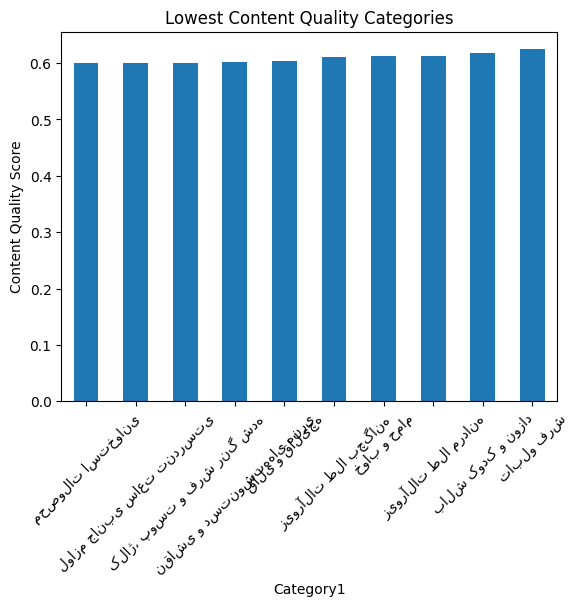

In [12]:
category_content.head(10)[
    "avg_content_score"
].plot(
    kind="bar"
)


plt.title(
    "Lowest Content Quality Categories"
)


plt.ylabel(
    "Content Quality Score"
)


plt.xticks(rotation=45)

plt.show()

# 8. Content Improvement Opportunities


Priority should be given to products with:


- Low content score
- High marketplace importance
- Low customer satisfaction


These products represent potential business impact.


In [14]:
improvement_candidates = (

    products

    .sort_values(
        [
            "Content_Quality_Score",
            "Rate"
        ]

    )

    [
        [
            "title_fa",
            "Category1",
            "Brand",
            "Rate",
            "Content_Quality_Score"
        ]
    ]

)


improvement_candidates.head(20)

,title_fa,Category1,Brand,Rate,Content_Quality_Score
22749,رنگ مو جیپسی شماره 10.0 حجم 100 میلی لیتر رنگ ...,آرایش مو,متفرقه,0,0.48
53384,ساختنی مدل ماینکرافت کد 1076-2,اسباب بازی,متفرقه,0,0.48
59175,عروسک اسب پونی مدل Unicorn01 ارتفاع 38 سانتیمتر,اسباب بازی,متفرقه,0,0.48
59812,اسباب بازی مدل فست فود طرح پیتزا کد 02,اسباب بازی,متفرقه,0,0.48
84957,ست ایفای نقش مدل بن تن کد bn01 مجموعه سه عددی,اسباب بازی,متفرقه,0,0.48
85269,اسباب بازی طرح چرخ اسنک و پاپ کورن مدل 333-1,اسباب بازی,متفرقه,0,0.48
93439,کیف رودوشی زنانه چرم لانکا مدل WB-01-113151042...,اکسسوری زنانه,چرم لانکا,0,0.48
128603,ساعت مچی عقربه ای زنانه کیو اند کیو مدل F01A-0...,اکسسوری زنانه,کیو اند کیو,0,0.48
132222,گردنبند زنانه اکسسوری مدل تمشک G-Plated N002,اکسسوری زنانه,اکسسورایز,0,0.48
142693,گوشواره زنانه ژوپینگ مدل U425,اکسسوری زنانه,ژوپینگ,0,0.48


# 9. Business Recommendations


Based on analysis:


## Content Team Actions


1. Improve incomplete product pages.


2. Prioritize categories with low content scores.


3. Monitor products with low rating and weak content.


4. Create automated content quality monitoring dashboards.


## AI Opportunities


Future automation possibilities:


- Automatic product description quality checking

- Missing information detection

- AI-generated content recommendations

- Content quality prediction models


# 10. Summary & Next Steps


## Completed:


✔ Defined content quality framework

✔ Created Content Completeness Score

✔ Created Content Quality Score

✔ Ranked categories by content performance

✔ Identified improvement opportunities



## Next Notebook:


# 05 - Customer Sentiment Analysis


We will analyze customer reviews using NLP:


- Text preprocessing

- Sentiment classification

- Customer pain point extraction

- AI-based review summarization
